In [1]:
from src.config import RAW_DATA_DIR
from src.data.loader import load_meld

from src.features.tfidf import TFIDFFeatures
from src.models.logistic_regression import LogisticRegressionClassifier

from src.evaluation.metrics import (
    evaluate,
    print_results,
    plot_confusion_matrix,
)

In [2]:
meld = load_meld(RAW_DATA_DIR / "meld")

In [3]:
features = TFIDFFeatures(
    ngram_range=(1, 1),
)

X_train = features.fit_transform(meld.train["text"])
X_test = features.transform(meld.test["text"])

In [4]:
y_train = meld.train["emotion"]
y_test = meld.test["emotion"]

In [5]:
model = LogisticRegressionClassifier()

model.fit(
    X_train,
    y_train,
)

In [6]:
pred = model.predict(X_test)


===== EVALUATION =====
Accuracy     : 0.5268
Macro F1     : 0.2410
Weighted F1  : 0.4444

Per-class metrics
--------------------------------------------------
Emotion        Precision      Recall          F1
anger             0.2973      0.0638      0.1050
disgust           1.0000      0.0147      0.0290
fear              0.0000      0.0000      0.0000
joy               0.4971      0.2139      0.2991
neutral           0.5375      0.9076      0.6752
sadness           0.5172      0.0721      0.1266
surprise          0.5286      0.3950      0.4521

Confusion Matrix
[[  22    0    0   19  276    0   28]
 [   3    1    0    1   58    0    5]
 [   6    0    0    1   39    2    2]
 [   8    0    0   86  288    5   15]
 [  24    0    2   43 1140    6   41]
 [   6    0    0   12  167   15    8]
 [   5    0    0   11  153    1  111]]


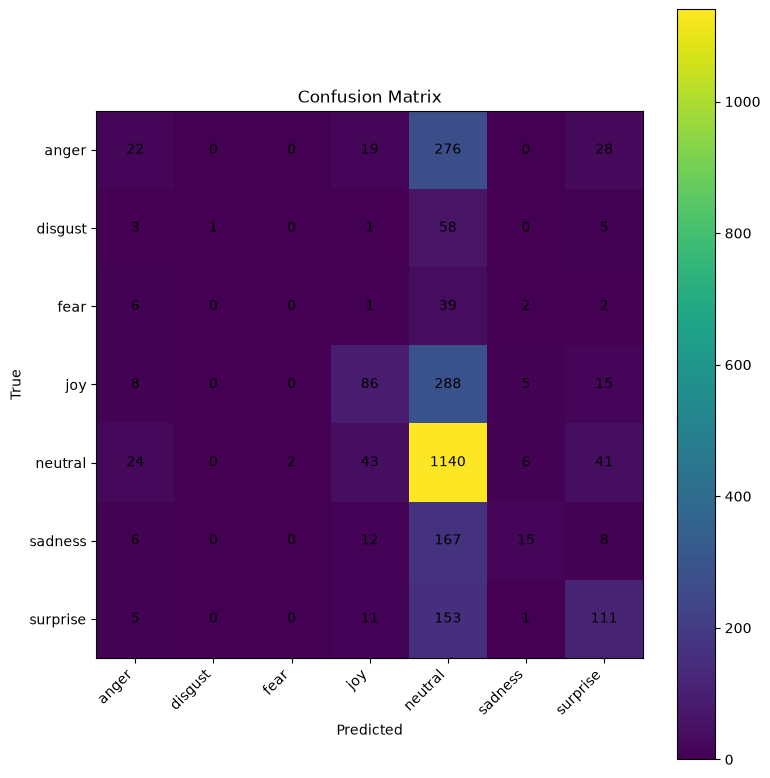

In [7]:
results = evaluate(
    y_test,
    pred,
)

print_results(results)

plot_confusion_matrix(results)